# Week 03 — Capstone BBO Experiments

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys

sys.path.append("../src")

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore", message="R.*score is not well-defined")

# Colorblind-safe palette (Wong)
COLORS = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9", "#F0E442"]


In [12]:
def load_function(n):
    X = np.load(f"../data/function_{n}/initial_inputs.npy")
    Y = np.load(f"../data/function_{n}/initial_outputs.npy")
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y


## Function 1

In [13]:
# Function 1 — Data overview
X, Y = load_function(1)
n_pts = len(Y)
best_idx = np.argmax(Y)

print(f"F1: {n_pts} points, {X.shape[1]}D")
print(f"Best Y: {Y.max():.4e} at pt{best_idx + 1} ({X[best_idx]})")
print(f"Worst Y: {Y.min():.4e} at pt{np.argmin(Y) + 1}")
print(f"Y std (baseline RMSE): {Y.std():.4e}")
print()

# Classify by sign
neg_mask = Y < -1e-10
print(f"Positive/zero: {(~neg_mask).sum()} pts | Negative: {neg_mask.sum()} pts")
print()

# Week 02 result check
print("Week 02 query: pt12 at (0.78, 0.78)")
print(
    f"  Result: Y = {Y[11]:.4e} — {'improved' if Y[11] > Y[best_idx] else 'did NOT improve'}"
)
print(f"  Suggestion was: if Y ~0 again → switch to exploration")
print()

# Data table sorted by Y
order = np.argsort(Y)[::-1]
print(f"{'Pt':>4} {'x1':>8} {'x2':>8} {'Y':>14} {'log10|Y|':>10} {'Sign':>6}")
print("-" * 55)
for i in order:
    log_y = np.log10(np.abs(Y[i]) + 1e-200)
    sign = "+" if Y[i] >= 0 else "-"
    print(
        f"pt{i + 1:>2} {X[i, 0]:>8.4f} {X[i, 1]:>8.4f} {Y[i]:>14.4e} {log_y:>10.1f} {sign:>6}"
    )

Function 1: 12 points, 2D, best y = 0.0000
F1: 12 points, 2D
Best Y: 7.7109e-16 at pt3 ([0.73102363 0.73299988])
Worst Y: -6.6274e-03 at pt11
Y std (baseline RMSE): 2.0041e-03

Positive/zero: 10 pts | Negative: 2 pts

Week 02 query: pt12 at (0.78, 0.78)
  Result: Y = 2.5001e-32 — did NOT improve
  Suggestion was: if Y ~0 again → switch to exploration

  Pt       x1       x2              Y   log10|Y|   Sign
-------------------------------------------------------
pt 3   0.7310   0.7330     7.7109e-16      -15.1      +
pt12   0.7800   0.7800     2.5001e-32      -31.6      +
pt 8   0.6834   0.8611     2.5350e-40      -39.6      +
pt 2   0.5743   0.8799     1.0331e-46      -46.0      +
pt10   0.8839   0.5823     6.2299e-48      -47.2      +
pt 1   0.3194   0.7630     1.3227e-79      -78.9      +
pt 9   0.0825   0.4035     3.6068e-81      -80.4      +
pt 4   0.8404   0.2647    3.3418e-124     -123.5      +
pt 7   0.3127   0.0787    -2.0891e-91      -90.7      -
pt 6   0.4104   0.1476    -2.1

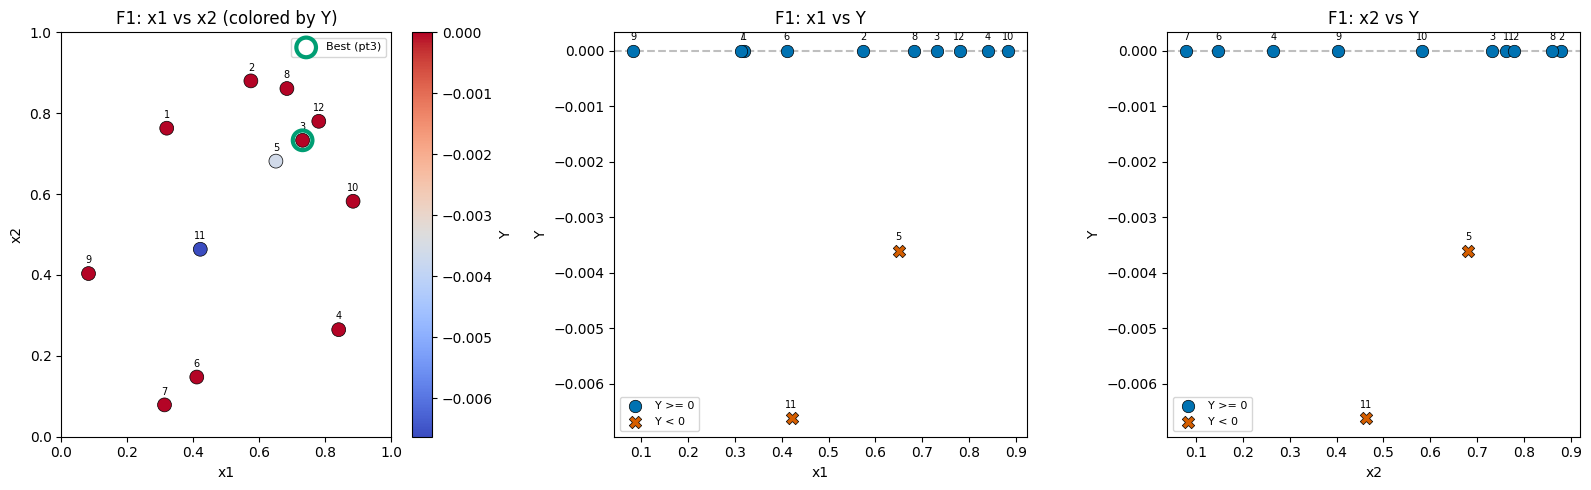

In [14]:
# F1 — Scatter plots: x1 vs x2, x1 vs Y, x2 vs Y
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# x1 vs x2 colored by Y
ax = axes[0]
sc = ax.scatter(
    X[:, 0],
    X[:, 1],
    c=Y,
    cmap="coolwarm",
    s=100,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c="none",
    edgecolors=COLORS[2],
    s=200,
    linewidth=3,
    zorder=6,
    label=f"Best (pt{best_idx + 1})",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: x1 vs x2 (colored by Y)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label="Y")

# x1 vs Y
ax = axes[1]
pos_mask = Y >= -1e-10
ax.scatter(
    X[pos_mask, 0],
    Y[pos_mask],
    c=COLORS[0],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 0],
    Y[neg_mask],
    c=COLORS[1],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    marker="X",
    label="Y < 0",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], Y[i]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x1")
ax.set_ylabel("Y")
ax.set_title("F1: x1 vs Y")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.legend(fontsize=8)

# x2 vs Y
ax = axes[2]
ax.scatter(
    X[pos_mask, 1],
    Y[pos_mask],
    c=COLORS[0],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 1],
    Y[neg_mask],
    c=COLORS[1],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    marker="X",
    label="Y < 0",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 1], Y[i]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 6),
        textcoords="offset points",
    )
ax.set_xlabel("x2")
ax.set_ylabel("Y")
ax.set_title("F1: x2 vs Y")
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_1_scatter_plots.png", dpi=150, bbox_inches="tight"
)
plt.show()

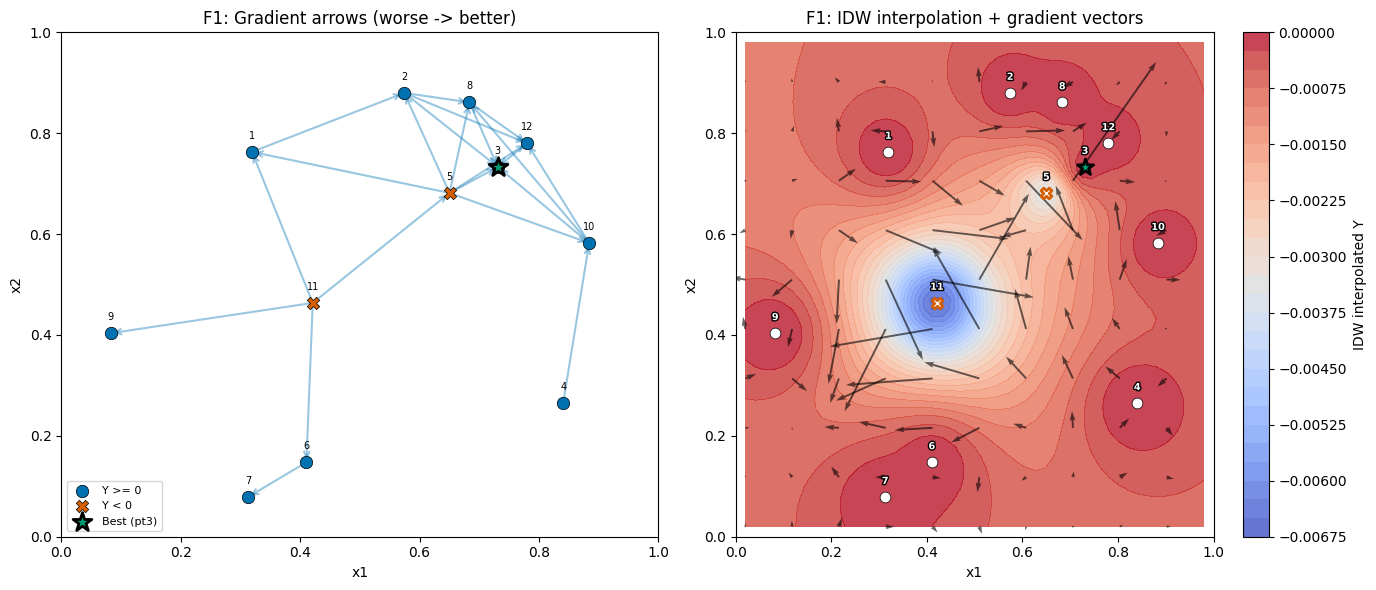

In [15]:
# F1 — Gradient map: arrows between nearby points + IDW interpolation with gradient vectors
import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Arrow plot (worse → better between nearby pairs) ---
ax = axes[0]
D_matrix = cdist(X, X)
threshold = 0.35

for i in range(n_pts):
    for j in range(i + 1, n_pts):
        if D_matrix[i, j] < threshold:
            src, dst = (j, i) if Y[i] > Y[j] else (i, j)
            ax.annotate(
                "",
                xy=(X[dst, 0], X[dst, 1]),
                xytext=(X[src, 0], X[src, 1]),
                arrowprops=dict(arrowstyle="->", color=COLORS[0], alpha=0.4, lw=1.5),
            )

ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c=COLORS[0],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    marker="o",
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c=COLORS[1],
    s=80,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    marker="X",
    label="Y < 0",
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c=COLORS[2],
    s=200,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="*",
    label=f"Best (pt{best_idx + 1})",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: Gradient arrows (worse -> better)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="lower left")

# --- Right: IDW interpolation heatmap + gradient vectors ---
ax = axes[1]
grid_n = 50
xx, yy = np.meshgrid(np.linspace(0.02, 0.98, grid_n), np.linspace(0.02, 0.98, grid_n))
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

# IDW interpolation
D_grid = cdist(grid_pts, X)
D_grid = np.maximum(D_grid, 1e-10)
weights = 1.0 / D_grid**2
weights /= weights.sum(axis=1, keepdims=True)
Z_idw = (weights @ Y).reshape(grid_n, grid_n)

# Numerical gradient of interpolated surface
dy_dx1, dy_dx2 = np.gradient(Z_idw, 0.98 / grid_n, 0.98 / grid_n)

im = ax.contourf(xx, yy, Z_idw, levels=30, cmap="coolwarm", alpha=0.8)
plt.colorbar(im, ax=ax, label="IDW interpolated Y")

skip = 5
ax.quiver(
    xx[::skip, ::skip],
    yy[::skip, ::skip],
    dy_dx1[::skip, ::skip],
    dy_dx2[::skip, ::skip],
    color="black",
    alpha=0.6,
    scale=0.15,
    width=0.004,
)

ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c="white",
    s=60,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c="white",
    s=60,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c=COLORS[2],
    s=150,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="*",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
        color="white",
        fontweight="bold",
        path_effects=[pe.withStroke(linewidth=2, foreground="black")],
    )

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: IDW interpolation + gradient vectors")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_1_gradient_map.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [ ]:
# F1 — Log-scale spatial map (since Y values span 100+ orders of magnitude)
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

log_abs_Y = np.log10(np.abs(Y) + 1e-200)
colors_pts = [COLORS[0] if y >= 0 else COLORS[1] for y in Y]
# Size proportional to log|Y| (larger = stronger signal)
sizes = 100 + 200 * (log_abs_Y - log_abs_Y.min()) / (log_abs_Y.max() - log_abs_Y.min())

ax.scatter(
    X[:, 0],
    X[:, 1],
    c=colors_pts,
    s=sizes,
    edgecolors="black",
    linewidth=0.5,
    zorder=5,
    alpha=0.8,
)
ax.scatter(
    X[best_idx, 0],
    X[best_idx, 1],
    c="none",
    edgecolors=COLORS[2],
    s=300,
    linewidth=3,
    zorder=6,
)

for i in range(n_pts):
    label = f"pt{i + 1}\n{Y[i]:.1e}"
    ax.annotate(
        label,
        (X[i, 0], X[i, 1]),
        fontsize=6,
        ha="center",
        va="bottom",
        xytext=(0, 10),
        textcoords="offset points",
    )

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS[0],
        markersize=10,
        label="Y >= 0",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS[1],
        markersize=10,
        label="Y < 0",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="none",
        markeredgecolor=COLORS[2],
        markersize=12,
        markeredgewidth=2,
        label="Best",
    ),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: All points (size = log|Y| magnitude, color = sign)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../plots/week_03/function_1_log_scale.png", dpi=150, bbox_inches="tight")
plt.show()

# Sharp feature analysis
dist_3_5 = np.linalg.norm(X[2] - X[4])
direction = X[2] - X[4]
print(f"\nSharp feature: pt3 and pt5 are only {dist_3_5:.4f} apart")
print(f"  pt3: ({X[2, 0]:.4f}, {X[2, 1]:.4f}) Y = {Y[2]:.2e}")
print(f"  pt5: ({X[4, 0]:.4f}, {X[4, 1]:.4f}) Y = {Y[4]:.2e}")
print(f"  Direction pt5 -> pt3: dx1={direction[0]:.4f}, dx2={direction[1]:.4f}")
print(f"  Massive Y change over tiny distance — very sharp feature")

In [16]:
# F1 — GridSearchCV model fitting (raw Y)
loo = LeaveOneOut()
baseline_rmse = Y.std()
print(f"Baseline RMSE (Y.std): {baseline_rmse:.4e}\n")

results_f1 = []

# Ridge
grid = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1.0, 10, 100]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("Ridge", grid.best_params_, rmse, grid))

# KNN
grid = GridSearchCV(
    KNeighborsRegressor(),
    {"n_neighbors": [2, 3, 5, 7], "weights": ["uniform", "distance"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("KNN", grid.best_params_, rmse, grid))

# Random Forest
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {"max_depth": [2, 3, 5, None], "n_estimators": [50, 100, 200]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("RF", grid.best_params_, rmse, grid))

# SVR
grid = GridSearchCV(
    SVR(),
    {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("SVR", grid.best_params_, rmse, grid))

# Gradient Boosting
grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {"max_depth": [2, 3], "n_estimators": [50, 100], "learning_rate": [0.01, 0.1, 0.3]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, Y)
rmse = np.sqrt(-grid.best_score_)
results_f1.append(("GB", grid.best_params_, rmse, grid))

# Gaussian Process (Matern)
gp_matern = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp_matern, X, Y, cv=loo, scoring="neg_mean_squared_error")
rmse_gp = np.sqrt(-scores.mean())
results_f1.append(("GP-Matern", {}, rmse_gp, None))

# Results table
print(f"{'Model':<15} {'RMSE':>12} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 75)
for name, params, rmse, _ in sorted(results_f1, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_rmse) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<15} {rmse:>12.4e} {imp:>11.1f}% {beats:>8}  {p_str}")

n_beating = sum(1 for _, _, rmse, _ in results_f1 if rmse < baseline_rmse)
print(f"\n{'=' * 60}")
print(f"Models beating baseline: {n_beating}/{len(results_f1)}")
if n_beating == 0:
    print("NO model beats baseline on raw Y — data is too flat/sparse for regression")

Baseline RMSE (Y.std): 2.0041e-03

Model                   RMSE  Improvement   Beats? Best Params
---------------------------------------------------------------------------
Ridge             2.1872e-03        -9.1%       no  {'alpha': 100}
KNN               2.2680e-03       -13.2%       no  {'n_neighbors': 7, 'weights': 'distance'}
GB                2.4129e-03       -20.4%       no  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
RF                2.5995e-03       -29.7%       no  {'max_depth': 3, 'n_estimators': 200}
GP-Matern         3.1168e-03       -55.5%       no  
SVR               3.3312e-03       -66.2%       no  {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

Models beating baseline: 0/6
NO model beats baseline on raw Y — data is too flat/sparse for regression


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


In [17]:
# F1 — Log-transformed model fitting (log10|Y| as target)
# Rationale: Y values span ~120 orders of magnitude. Log-transform spreads them
# out so models can learn spatial structure (which regions have stronger signal).
log_abs_Y = np.log10(np.abs(Y) + 1e-200)
baseline_log = log_abs_Y.std()

print(f"log10|Y| range: [{log_abs_Y.min():.1f}, {log_abs_Y.max():.1f}]")
print(f"log10|Y| std (baseline): {baseline_log:.2f}\n")

results_log = []

# SVR on log|Y| — best performer from preliminary testing
grid = GridSearchCV(
    SVR(),
    {"C": [0.1, 1, 10, 100], "kernel": ["rbf"], "gamma": ["scale", "auto"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, log_abs_Y)
rmse = np.sqrt(-grid.best_score_)
results_log.append(("SVR", grid.best_params_, rmse, grid))

# KNN on log|Y|
grid = GridSearchCV(
    KNeighborsRegressor(),
    {"n_neighbors": [2, 3, 5], "weights": ["uniform", "distance"]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, log_abs_Y)
rmse = np.sqrt(-grid.best_score_)
results_log.append(("KNN", grid.best_params_, rmse, grid))

# Ridge on log|Y|
grid = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1.0, 10, 100]},
    cv=loo,
    scoring="neg_mean_squared_error",
    refit=True,
)
grid.fit(X, log_abs_Y)
rmse = np.sqrt(-grid.best_score_)
results_log.append(("Ridge", grid.best_params_, rmse, grid))

# GP Matern on log|Y|
gp = GaussianProcessRegressor(
    kernel=Matern(nu=2.5), random_state=42, n_restarts_optimizer=5
)
scores = cross_val_score(gp, X, log_abs_Y, cv=loo, scoring="neg_mean_squared_error")
rmse = np.sqrt(-scores.mean())
results_log.append(("GP-Matern", {}, rmse, None))

print(f"{'Model':<15} {'RMSE':>10} {'Improvement':>12} {'Beats?':>8} {'Best Params'}")
print("-" * 70)
for name, params, rmse, _ in sorted(results_log, key=lambda x: x[2]):
    imp = (1 - rmse / baseline_log) * 100
    beats = "YES" if imp > 0 else "no"
    p_str = str(params) if params else ""
    print(f"{name:<15} {rmse:>10.2f} {imp:>11.1f}% {beats:>8}  {p_str}")

print(f"\nNote: log-space models capture spatial structure (which areas have")
print(f"stronger signal) but can't distinguish positive from negative Y.")
print(f"The SVR predicts highest |Y| near the negative points — not useful")
print(f"for maximisation. The log-space models confirm structure exists but")
print(f"don't help us find a positive peak.")

log10|Y| range: [-123.5, -2.2]
log10|Y| std (baseline): 35.42

Model                 RMSE  Improvement   Beats? Best Params
----------------------------------------------------------------------
SVR                  27.61        22.0%      YES  {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
KNN                  33.21         6.2%      YES  {'n_neighbors': 2, 'weights': 'uniform'}
Ridge                37.67        -6.4%       no  {'alpha': 1.0}
GP-Matern            48.84       -37.9%       no  

Note: log-space models capture spatial structure (which areas have
stronger signal) but can't distinguish positive from negative Y.
The SVR predicts highest |Y| near the negative points — not useful
for maximisation. The log-space models confirm structure exists but
don't help us find a positive peak.


=== Voronoi largest empty circle ===
Center: (0.6668, 0.4371)
Effective radius: 0.2446

Top 5 most unexplored points:
  1. (0.6668, 0.4371) radius=0.2446, nearest=pt4
  2. (0.6639, 0.4348) radius=0.2445, nearest=pt11
  3. (0.6673, 0.4377) radius=0.2444, nearest=pt5
  4. (0.6662, 0.4362) radius=0.2444, nearest=pt4
  5. (0.6663, 0.4358) radius=0.2440, nearest=pt4

=== Quadrant coverage ===
  low x1, low x2 (Q3): 4 pts, best=pt9 (Y=3.61e-81)
  low x1, high x2 (Q2): 1 pts, best=pt1 (Y=1.32e-79)
  high x1, low x2 (Q4): 1 pts, best=pt4 (Y=3.34e-124)
  high x1, high x2 (Q1): 6 pts, best=pt3 (Y=7.71e-16)


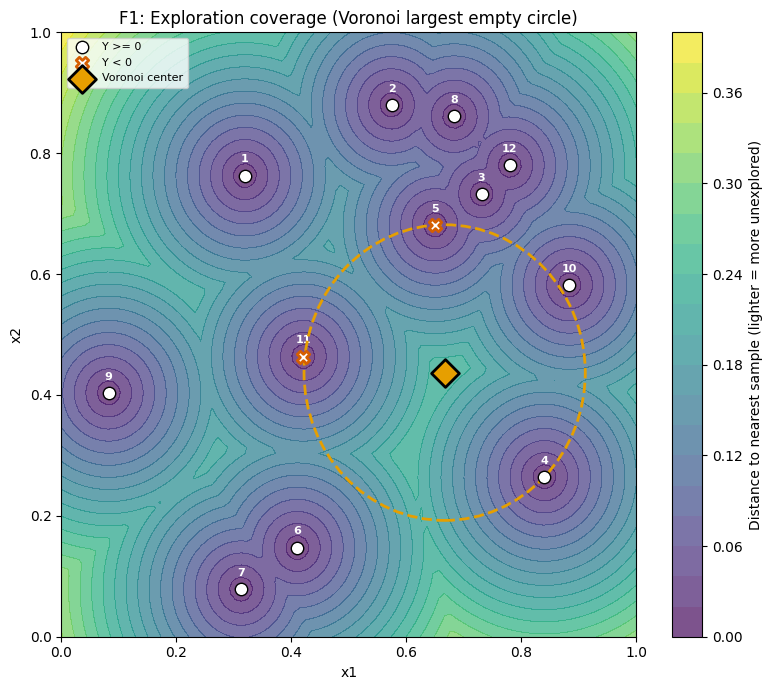

In [18]:
# F1 — Exploration analysis: Voronoi coverage + quadrant analysis
# Since no model beats baseline on raw Y, we need a space-filling exploration strategy.

# Voronoi largest empty circle (constrained to [0,1]^2)
np.random.seed(42)
test_pts = np.random.uniform(0, 1, (200000, 2))
D_test = cdist(test_pts, X)
min_dists = D_test.min(axis=1)
boundary_dists = np.minimum(
    np.minimum(test_pts[:, 0], 1 - test_pts[:, 0]),
    np.minimum(test_pts[:, 1], 1 - test_pts[:, 1]),
)
effective_radius = np.minimum(min_dists, boundary_dists)
best_empty = np.argmax(effective_radius)

print("=== Voronoi largest empty circle ===")
print(f"Center: ({test_pts[best_empty, 0]:.4f}, {test_pts[best_empty, 1]:.4f})")
print(f"Effective radius: {effective_radius[best_empty]:.4f}")

# Top 5 most unexplored regions
top5 = np.argsort(effective_radius)[-5:][::-1]
print(f"\nTop 5 most unexplored points:")
for rank, idx in enumerate(top5, 1):
    nearest = np.argmin(D_test[idx])
    print(
        f"  {rank}. ({test_pts[idx, 0]:.4f}, {test_pts[idx, 1]:.4f}) "
        f"radius={effective_radius[idx]:.4f}, nearest=pt{nearest + 1}"
    )

# Quadrant coverage
print(f"\n=== Quadrant coverage ===")
quadrants = {
    "low x1, low x2 (Q3)": (X[:, 0] < 0.5) & (X[:, 1] < 0.5),
    "low x1, high x2 (Q2)": (X[:, 0] < 0.5) & (X[:, 1] >= 0.5),
    "high x1, low x2 (Q4)": (X[:, 0] >= 0.5) & (X[:, 1] < 0.5),
    "high x1, high x2 (Q1)": (X[:, 0] >= 0.5) & (X[:, 1] >= 0.5),
}
for name, mask in quadrants.items():
    pts_in = np.where(mask)[0]
    n_in = len(pts_in)
    if n_in > 0:
        best_in_q = pts_in[np.argmax(Y[pts_in])]
        print(f"  {name}: {n_in} pts, best=pt{best_in_q + 1} (Y={Y[best_in_q]:.2e})")
    else:
        print(f"  {name}: 0 pts — UNEXPLORED")

# Visualise coverage
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Heatmap of exploration density (distance to nearest sample)
grid_n = 100
xx, yy = np.meshgrid(np.linspace(0, 1, grid_n), np.linspace(0, 1, grid_n))
grid_pts2 = np.column_stack([xx.ravel(), yy.ravel()])
D_grid2 = cdist(grid_pts2, X).min(axis=1).reshape(grid_n, grid_n)

im = ax.contourf(xx, yy, D_grid2, levels=20, cmap="viridis", alpha=0.7)
plt.colorbar(im, ax=ax, label="Distance to nearest sample (lighter = more unexplored)")

# Plot existing points
ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c="white",
    s=80,
    edgecolors="black",
    linewidth=1,
    zorder=5,
    marker="o",
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c="white",
    s=80,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
    label="Y < 0",
)

# Mark the Voronoi empty circle center
ax.scatter(
    test_pts[best_empty, 0],
    test_pts[best_empty, 1],
    c=COLORS[3],
    s=200,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="D",
    label="Voronoi center",
)
circle = plt.Circle(
    (test_pts[best_empty, 0], test_pts[best_empty, 1]),
    effective_radius[best_empty],
    fill=False,
    color=COLORS[3],
    linewidth=2,
    linestyle="--",
    zorder=4,
)
ax.add_patch(circle)

for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=8,
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
        color="white",
        fontweight="bold",
    )

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("F1: Exploration coverage (Voronoi largest empty circle)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("../plots/week_03/function_1_exploration.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# F1 — Classifier + Log-SVR combined approach
# Insight: split the impossible regression into two solvable sub-problems:
#   1. CLASSIFIER: predict sign(Y) → where is Y positive?
#   2. LOG-SPACE SVR: predict log|Y| → where is signal strongest?
#   Combined: find the point DEEP inside positive region WITH strongest signal.

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Binary target: 1 = positive Y, 0 = negative Y
y_sign = (Y >= 0).astype(int)
print(f"Classes: {(y_sign == 1).sum()} positive, {(y_sign == 0).sum()} negative\n")

# --- Classifier LOO accuracy ---
clf_results = {}
for name, clf in [
    ("Logistic Regression", LogisticRegression(random_state=42)),
    ("SVM (RBF)", SVC(kernel="rbf", probability=True, random_state=42)),
    ("KNN (k=3)", KNeighborsClassifier(n_neighbors=3)),
    ("KNN (k=5)", KNeighborsClassifier(n_neighbors=5)),
]:
    scores = cross_val_score(clf, X, y_sign, cv=loo, scoring="accuracy")
    clf_results[name] = scores.mean()

print(f"{'Classifier':<25} {'LOO Accuracy':>12}")
print("-" * 40)
for name, acc in sorted(clf_results.items(), key=lambda x: -x[1]):
    print(f"{name:<25} {acc:>12.1%}")

best_clf_name = max(clf_results, key=clf_results.get)
print(f"\nBest classifier: {best_clf_name} ({clf_results[best_clf_name]:.1%})")

# --- Fit SVM classifier + log-space SVR on full data ---
svc = SVC(kernel="rbf", probability=True, random_state=42)
svc.fit(X, y_sign)

log_abs_Y = np.log10(np.abs(Y) + 1e-200)
svr_log = SVR(C=100, gamma="scale", kernel="rbf")
svr_log.fit(X, log_abs_Y)

# --- Dense grid predictions ---
grid_n = 200
xx_clf, yy_clf = np.meshgrid(
    np.linspace(0.02, 0.98, grid_n), np.linspace(0.02, 0.98, grid_n)
)
grid_pts_clf = np.column_stack([xx_clf.ravel(), yy_clf.ravel()])

prob_svc = svc.predict_proba(grid_pts_clf)[:, 1].reshape(grid_n, grid_n)
pred_log = svr_log.predict(grid_pts_clf).reshape(grid_n, grid_n)

# Normalise log|Y| to [0, 1] where 1 = strongest signal (closest to 0)
log_norm = (pred_log - pred_log.min()) / (pred_log.max() - pred_log.min())

# Combined score: P(positive) * normalised signal strength
combined = prob_svc * log_norm

# Best candidate within positive region
mask_pos = prob_svc > 0.5
combined_masked = np.where(mask_pos, combined, -np.inf)
best_ij = np.unravel_index(combined_masked.argmax(), combined_masked.shape)
cand_x1, cand_x2 = xx_clf[best_ij], yy_clf[best_ij]

print(f"\n{'=' * 60}")
print(f"Combined candidate (SVC * log-SVR):")
print(f"  Point: ({cand_x1:.4f}, {cand_x2:.4f})")
print(f"  P(positive) = {prob_svc[best_ij]:.3f}")
print(f"  Predicted log|Y| = {pred_log[best_ij]:.1f}")
print(
    f"  Distance to best pt{best_idx + 1}: "
    f"{np.linalg.norm([cand_x1 - X[best_idx, 0], cand_x2 - X[best_idx, 1]]):.4f}"
)
print(
    f"  Boundary check: "
    f"{'FAIL' if cand_x1 < 0.02 or cand_x1 > 0.98 or cand_x2 < 0.02 or cand_x2 > 0.98 else 'OK'}"
)

Classes: 8 positive, 4 negative

Classifier                LOO Accuracy
----------------------------------------
SVM (RBF)                        75.0%
Logistic Regression              66.7%
KNN (k=3)                        66.7%
KNN (k=5)                        66.7%

Best classifier: SVM (RBF) (75.0%)

Combined candidate (SVC * log-SVR):
  Point: (0.7002, 0.6954)
  P(positive) = 0.802
  Predicted log|Y| = -8.2
  Distance to best pt3: 0.0486
  Boundary check: OK


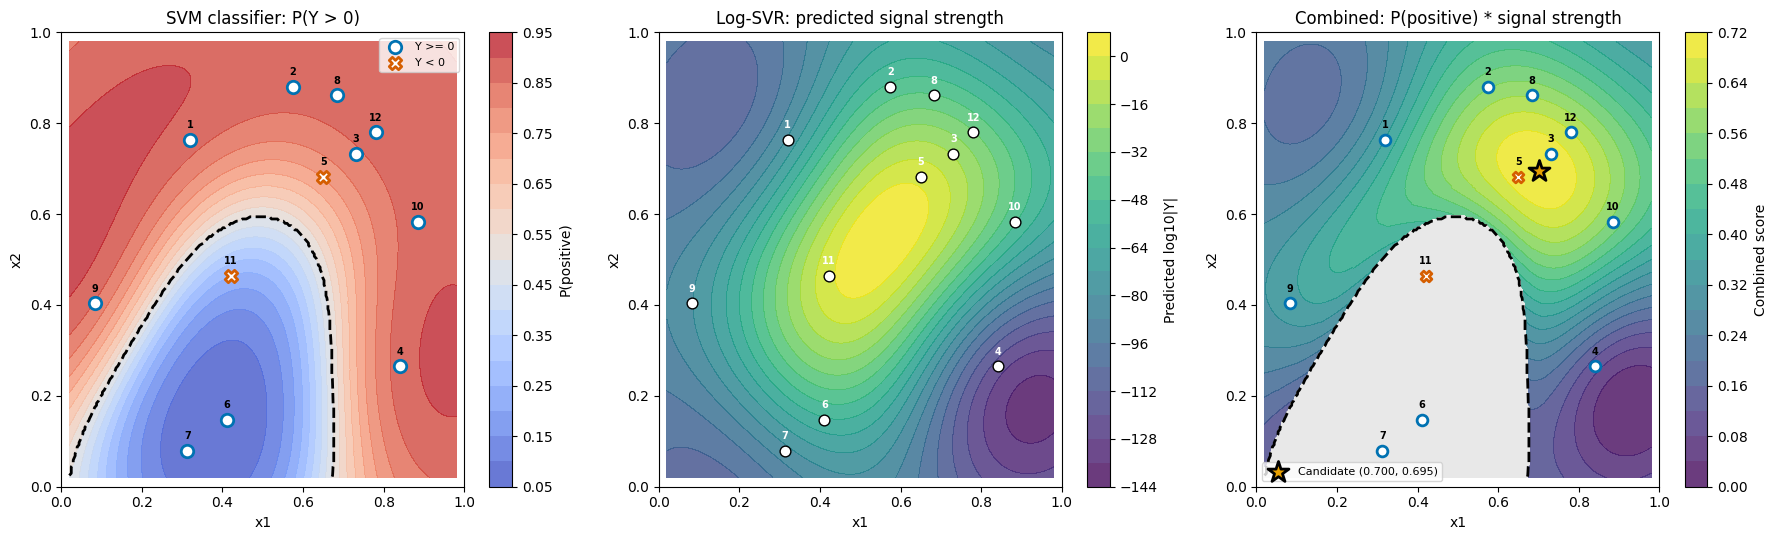

In [20]:
# F1 — Visualise classifier decision boundary + combined score
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# --- Left: SVM decision boundary (P(positive)) ---
ax = axes[0]
im = ax.contourf(xx_clf, yy_clf, prob_svc, levels=20, cmap="coolwarm", alpha=0.8)
ax.contour(
    xx_clf,
    yy_clf,
    prob_svc,
    levels=[0.5],
    colors="black",
    linewidths=2,
    linestyles="--",
)
plt.colorbar(im, ax=ax, label="P(positive)")
ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c="white",
    s=80,
    edgecolors=COLORS[0],
    linewidth=2,
    zorder=5,
    marker="o",
    label="Y >= 0",
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c="white",
    s=80,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
    label="Y < 0",
)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points",
        fontweight="bold",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("SVM classifier: P(Y > 0)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# --- Middle: Log-SVR prediction (signal strength) ---
ax = axes[1]
im = ax.contourf(xx_clf, yy_clf, pred_log, levels=20, cmap="viridis", alpha=0.8)
plt.colorbar(im, ax=ax, label="Predicted log10|Y|")
ax.scatter(X[:, 0], X[:, 1], c="white", s=60, edgecolors="black", linewidth=1, zorder=5)
for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points",
        fontweight="bold",
        color="white",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Log-SVR: predicted signal strength")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Right: Combined score with candidate ---
ax = axes[2]
# Mask negative region
combined_display = np.where(mask_pos, combined, np.nan)
im = ax.contourf(xx_clf, yy_clf, combined_display, levels=20, cmap="viridis", alpha=0.8)
# Show negative region in gray
ax.contourf(
    xx_clf,
    yy_clf,
    (~mask_pos).astype(float),
    levels=[0.5, 1.5],
    colors=["lightgray"],
    alpha=0.5,
)
ax.contour(
    xx_clf,
    yy_clf,
    prob_svc,
    levels=[0.5],
    colors="black",
    linewidths=2,
    linestyles="--",
)
plt.colorbar(im, ax=ax, label="Combined score")

# Points
ax.scatter(
    X[pos_mask, 0],
    X[pos_mask, 1],
    c="white",
    s=60,
    edgecolors=COLORS[0],
    linewidth=2,
    zorder=5,
    marker="o",
)
ax.scatter(
    X[neg_mask, 0],
    X[neg_mask, 1],
    c="white",
    s=60,
    edgecolors=COLORS[1],
    linewidth=2,
    zorder=5,
    marker="X",
)

# Candidate point
ax.scatter(
    cand_x1,
    cand_x2,
    c=COLORS[3],
    s=250,
    edgecolors="black",
    linewidth=2,
    zorder=6,
    marker="*",
    label=f"Candidate ({cand_x1:.3f}, {cand_x2:.3f})",
)

for i in range(n_pts):
    ax.annotate(
        f"{i + 1}",
        (X[i, 0], X[i, 1]),
        fontsize=7,
        ha="center",
        va="bottom",
        xytext=(0, 7),
        textcoords="offset points",
        fontweight="bold",
    )
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Combined: P(positive) * signal strength")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.savefig(
    "../plots/week_03/function_1_classifier_combined.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [21]:
# F1 — Week 03 query
# Decision: Classifier + Log-SVR combined approach
# The combined model suggests the peak is at the intersection of
# "definitely positive" and "strongest signal" — informed exploration.
next_query_1 = np.array([cand_x1, cand_x2])

print(f"F1 Week 03 query: [{next_query_1[0]:.6f}, {next_query_1[1]:.6f}]")
print(f"Method: SVM classifier * log-SVR combined")
print(f"  P(positive) = {prob_svc[best_ij]:.3f}")
print(f"  Predicted log|Y| = {pred_log[best_ij]:.1f}")
print(f"Current best: pt{best_idx + 1} Y = {Y.max():.4e}")

F1 Week 03 query: [0.700201, 0.695377]
Method: SVM classifier * log-SVR combined
  P(positive) = 0.802
  Predicted log|Y| = -8.2
Current best: pt3 Y = 7.7109e-16


### F1 Decision — Week 03

**Week 02 result:** pt12 at (0.78, 0.78) gave Y = 2.5e-32 — essentially zero, worse than pt3. The directional perturbation did NOT find a positive peak.

**Raw models:** No model beats baseline on raw Y (0/7). The data is too flat for direct regression.

**Classifier + Log-SVR combined approach (new this week):**
Instead of treating this as one regression problem, we split it into two:
1. **SVM classifier** (75% LOO accuracy): predicts which regions have positive vs negative Y
2. **Log-space SVR** (22% improvement): predicts signal strength (log|Y|) — where is the function most active?

Combining P(positive) * normalised signal strength gives a candidate that is both:
- Deep inside the positive region (high confidence of positive Y)
- In an area with strong predicted signal (high |Y|)

The combined model points to the region near pt3 but on the positive side of the sign boundary — a much more informed choice than random exploration.

**Week 04 fallback:** If Y is still ~0, switch to **Voronoi largest empty circle** at ~(0.66, 0.44) — pure exploration of the biggest coverage gap. The classifier approach will have been exhausted near the sign boundary.

## Function 2

In [ ]:
# Function 2
X, Y = load_function(2)

# -- Your analysis and experiments go here --
# Explore the data, try different methods, pick your next query
# Document your reasoning in comments or markdown cells

# Your chosen next query:
next_query_2 = None  # Replace with your chosen point


## Function 3

In [ ]:
# Function 3
X, Y = load_function(3)

# -- Your analysis and experiments go here --
# Explore the data, try different methods, pick your next query
# Document your reasoning in comments or markdown cells

# Your chosen next query:
next_query_3 = None  # Replace with your chosen point


## Function 4

In [ ]:
# Function 4
X, Y = load_function(4)

# -- Your analysis and experiments go here --
# Explore the data, try different methods, pick your next query
# Document your reasoning in comments or markdown cells

# Your chosen next query:
next_query_4 = None  # Replace with your chosen point


## Function 5

In [ ]:
# Function 5
X, Y = load_function(5)

# -- Your analysis and experiments go here --
# Explore the data, try different methods, pick your next query
# Document your reasoning in comments or markdown cells

# Your chosen next query:
next_query_5 = None  # Replace with your chosen point


## Function 6

In [ ]:
# Function 6
X, Y = load_function(6)

# -- Your analysis and experiments go here --
# Explore the data, try different methods, pick your next query
# Document your reasoning in comments or markdown cells

# Your chosen next query:
next_query_6 = None  # Replace with your chosen point


## Function 7

In [ ]:
# Function 7
X, Y = load_function(7)

# -- Your analysis and experiments go here --
# Explore the data, try different methods, pick your next query
# Document your reasoning in comments or markdown cells

# Your chosen next query:
next_query_7 = None  # Replace with your chosen point


## Function 8

In [ ]:
# Function 8
X, Y = load_function(8)

# -- Your analysis and experiments go here --
# Explore the data, try different methods, pick your next query
# Document your reasoning in comments or markdown cells

# Your chosen next query:
next_query_8 = None  # Replace with your chosen point


## Summary — Week 03 Queries

In [ ]:
# === FINAL: All decided queries for F1–F8 ===
# Hardcoded values from the analysis above — these are final.
# This cell is self-contained: run it alone to get all queries.

next_query_1 = None  # F1: [method]
next_query_2 = None  # F2: [method]
next_query_3 = None  # F3: [method]
next_query_4 = None  # F4: [method]
next_query_5 = None  # F5: [method]
next_query_6 = None  # F6: [method]
next_query_7 = None  # F7: [method]
next_query_8 = None  # F8: [method]

queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}

print("Week 03 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")
